In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


os.makedirs('../images', exist_ok=True)
print("images/ folder ready")

images/ folder ready


In [5]:
telco = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
print(telco.shape)

telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco['ChurnFlag'] = telco['Churn'].map({'No': 0, 'Yes': 1})

print(telco.shape)

(7043, 21)
(7043, 22)


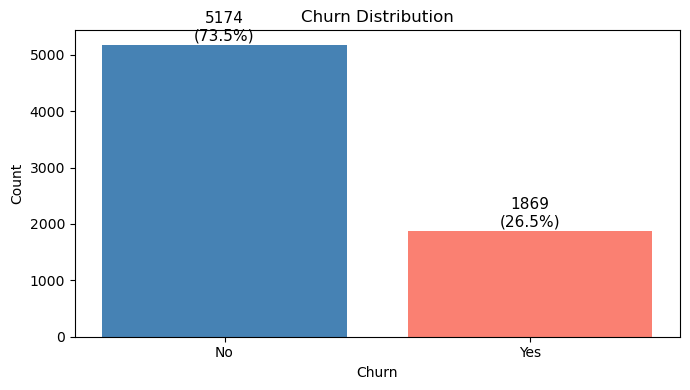

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

counts = telco['Churn'].value_counts()
percentages = telco['Churn'].value_counts(normalize=True) * 100

bars = ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'])

for bar, count, pct in zip(bars, counts.values, percentages.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count}\n({pct:.1f}%)",          
        ha='center', va='bottom', fontsize=11
    )

ax.set_title("Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig('../images/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

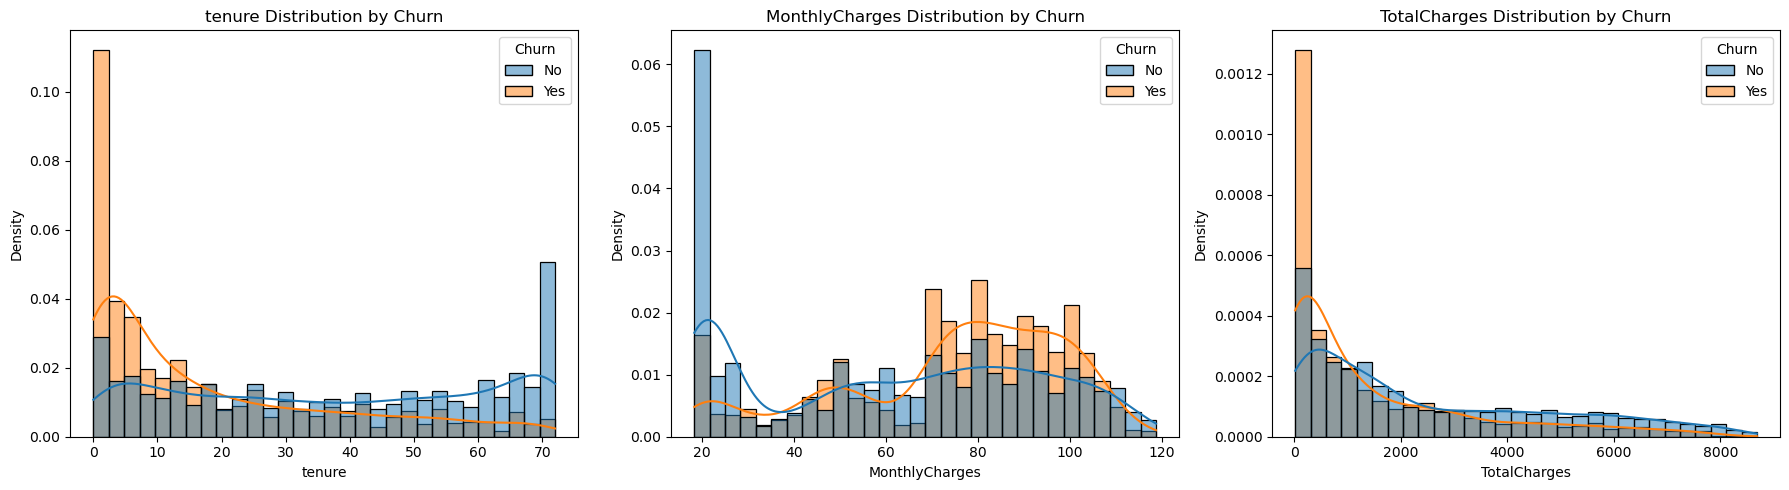

In [7]:

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=telco,
        x=col,
        hue='Churn',
        bins=30,
        kde=True,
        stat='density',
        common_norm=False,
        ax=ax
    )

    ax.set_title(f'{col} Distribution by Churn')

plt.tight_layout()
plt.savefig('../images/02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

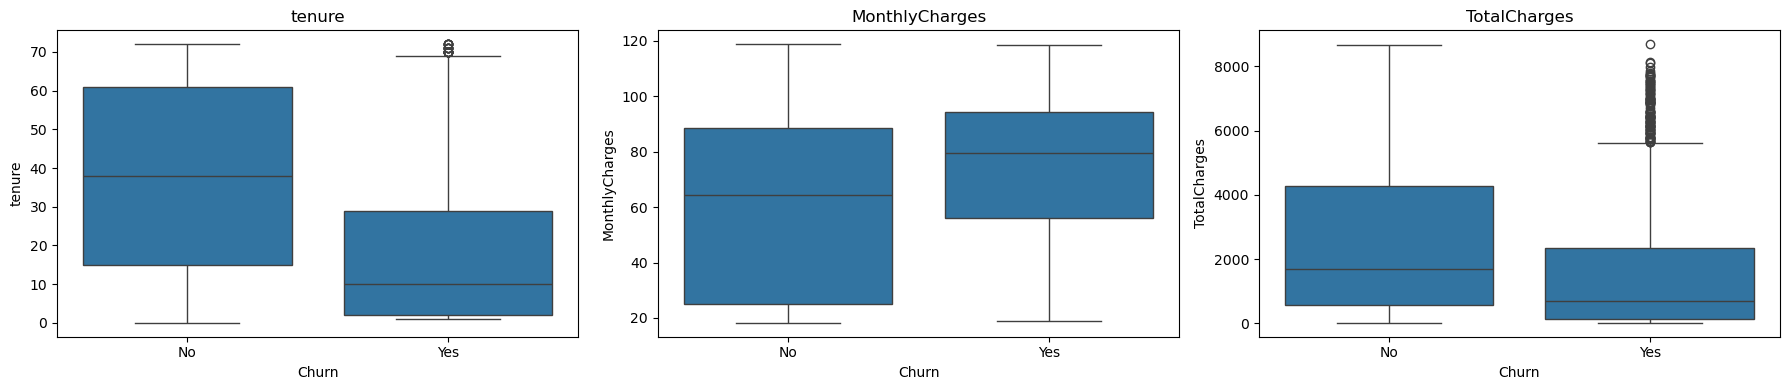

In [8]:

fig, axes = plt.subplots(1, 3, figsize=[18, 4])

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        data=telco,
        x='Churn',
        y=col,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.savefig('../images/03_numeric_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

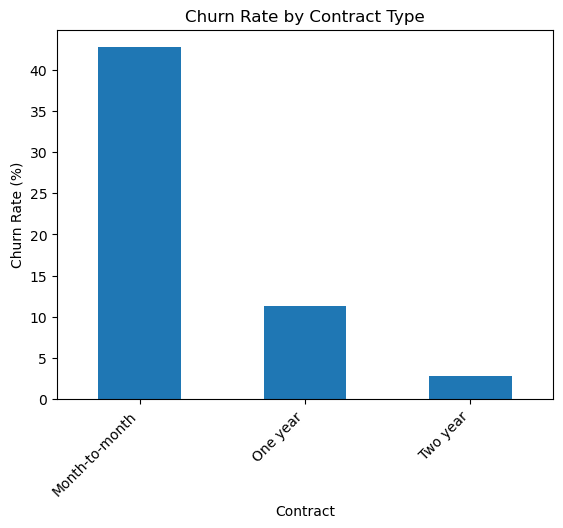

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64

In [9]:
contract_churn = (
    telco.groupby('Contract')['ChurnFlag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

contract_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type')
plt.xticks(rotation=45, ha='right')
plt.savefig('../images/04_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

contract_churn

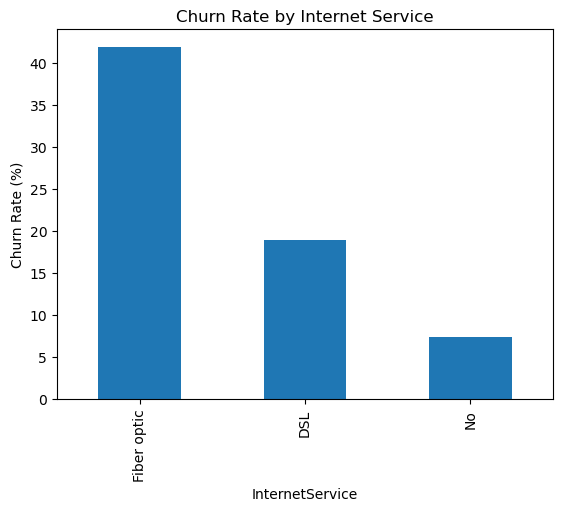

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: ChurnFlag, dtype: float64

In [10]:
internet_churn = (
    telco.groupby('InternetService')['ChurnFlag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

internet_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Internet Service')
plt.savefig('../images/05_churn_by_internet_service.png', dpi=150, bbox_inches='tight')
plt.show()

internet_churn

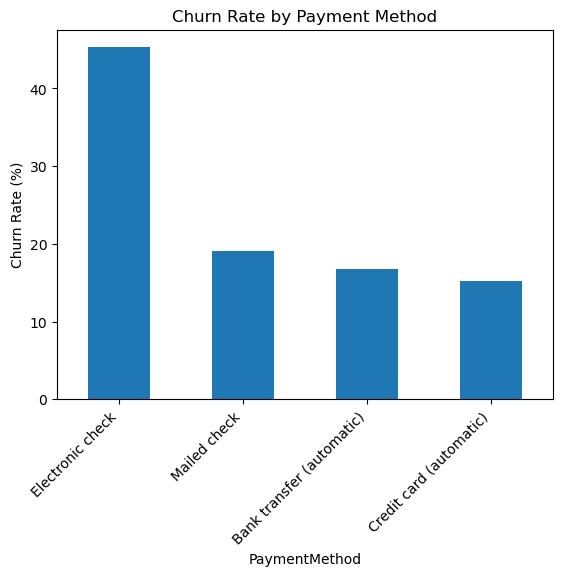

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: ChurnFlag, dtype: float64

In [15]:
payment_churn = (
    telco.groupby('PaymentMethod')['ChurnFlag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

payment_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Payment Method')
plt.xticks(rotation=45, ha='right')
plt.savefig('../images/06_churn_by_payment_method.png', dpi=150, bbox_inches='tight')
plt.show()

payment_churn

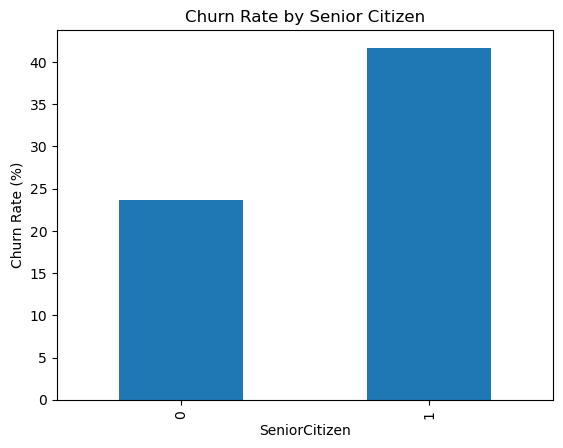

SeniorCitizen
0    23.606168
1    41.681261
Name: ChurnFlag, dtype: float64

In [16]:
senior_churn = (
    telco.groupby('SeniorCitizen')['ChurnFlag']
    .mean()
    .mul(100)
)

senior_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Senior Citizen')
plt.savefig('../images/07_churn_by_senior_citizen.png', dpi=150, bbox_inches='tight')
plt.show()

senior_churn

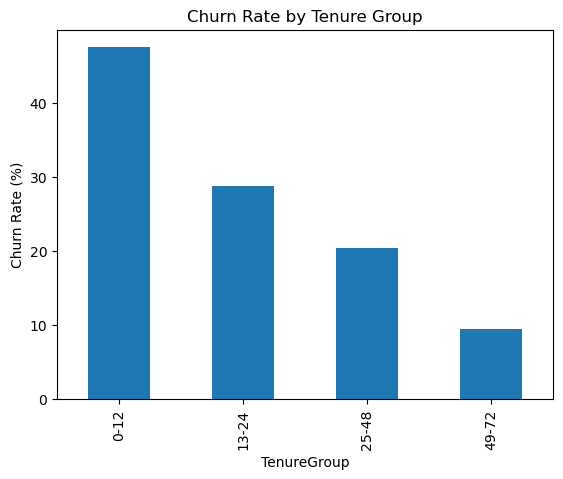

TenureGroup
0-12     47.438243
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: ChurnFlag, dtype: float64

In [13]:
tenure_churn = (
    telco.assign(
        TenureGroup=pd.cut(
            telco['tenure'],
            bins=[0, 12, 24, 48, 72],
            labels=['0-12', '13-24', '25-48', '49-72'],
            include_lowest=True
        )
    )
    .groupby('TenureGroup', observed=True)['ChurnFlag']
    .mean()
    .mul(100)
)

tenure_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Tenure Group')
plt.savefig('../images/08_churn_by_tenure_group.png', dpi=150, bbox_inches='tight')
plt.show()

tenure_churn

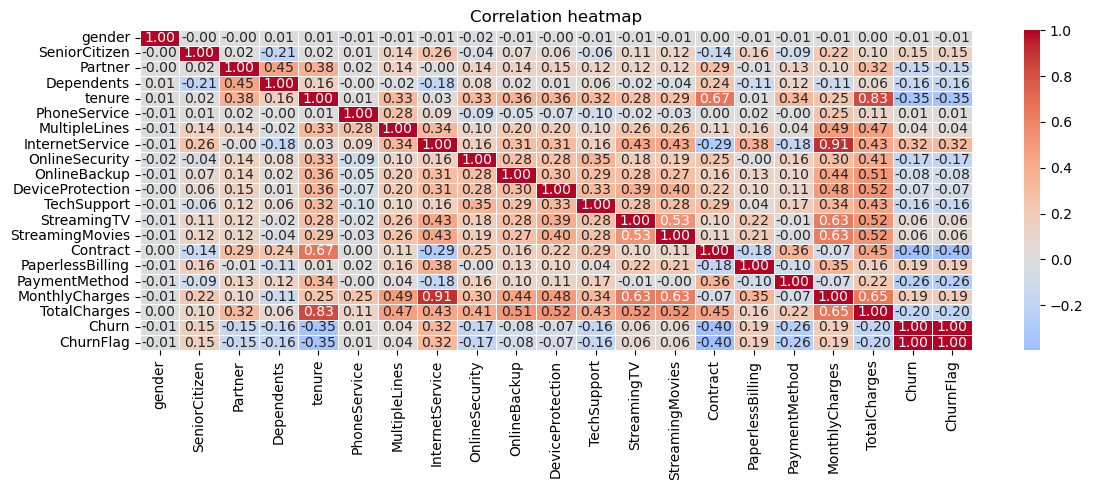

In [14]:
encode_map = {
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0,
    'No internet service': 0, 'No phone service': 0,
    'Month-to-month': 0, 'One year': 1, 'Two year': 2,
    'DSL': 1, 'Fiber optic': 2,
    'Electronic check': 0, 'Mailed check': 1,
    'Bank transfer (automatic)': 2, 'Credit card (automatic)': 3
}

telco_corr = telco.copy()
for col in telco_corr.select_dtypes(include=['object', 'str']).columns:
    telco_corr[col] = telco_corr[col].map(encode_map)

corr = telco_corr.drop(columns=['customerID', 'TenureGroup'], errors='ignore').corr()

plt.figure(figsize=(12, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig('../images/09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Key Findings from EDA

- **Churn rate:** 26.5% of customers churned (1,869 out of 7,043)
- **Contract type is the strongest categorical signal:** month-to-month customers churn at 42.7% vs 11.3% for one-year and just 2.8% for two-year contracts
- **Fiber optic drives the highest internet-related churn:** 41.9% churn rate vs 19.0% for DSL and 7.4% for customers with no internet service
- **Electronic check payment is a strong churn signal:** 45.3% churn rate — nearly 3× higher than bank transfer (16.7%) or credit card (15.2%)
- **Senior citizens churn at 41.7%** — almost double the 23.6% rate for non-seniors
- **Tenure is the clearest numeric separator:** churned customers leave early — 0–12 month customers churn at 47.4%, dropping to 9.5% for 49–72 month customers
- **Monthly charges:** churned customers pay higher monthly charges on average — the distribution for churners is skewed toward higher values
- **TotalCharges:** lower for churned customers despite higher monthly charges — confirms they leave earlier, accumulating less total spend

### Next step
Data cleaning (03_data_cleaning.ipynb) — drop the 11 blank TotalCharges rows, encode binary columns, collapse 3-value service columns to 0/1, encode remaining categoricals, drop customerID.